In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# EDA

## Members

user information. Note that not every user in the dataset is available.

    msno
    city
    bd: age. Note: this column has outlier values ranging from -7000 to 2015, please use your judgement.
    gender
    registered_via: registration method
    registration_init_time: format %Y%m%d
    expiration_date: format %Y%m%d, taken as a snapshot at which the member.csv is extracted. Not representing the actual churn behavior.


In [4]:
df_members = pd.read_csv('../data/raw/members_v3.csv')

In [5]:
df_members.head()

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [10]:
df_members.shape

(6769473, 6)

In [18]:
df_members["city"] = df_members.city.astype('category')

<Axes: >

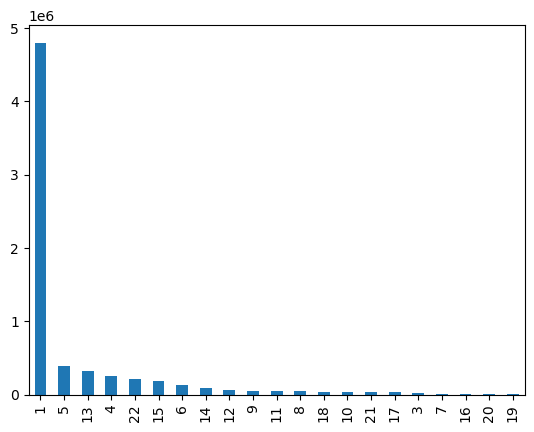

In [22]:
df_members.city.value_counts().plot(kind="bar")

In [39]:
df_members['registered_via'] = df_members.registered_via.astype('category')

<Axes: >

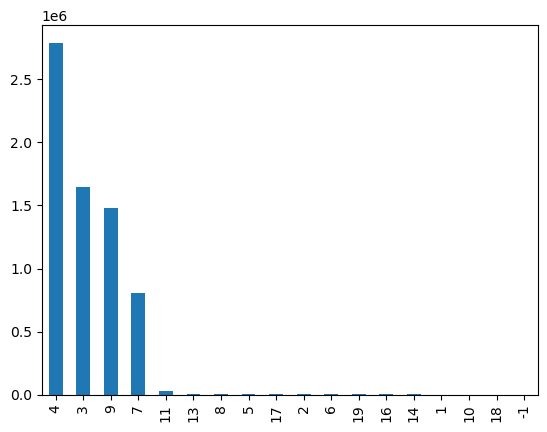

In [41]:
df_members['registered_via'].value_counts().plot(kind='bar')

<Axes: >

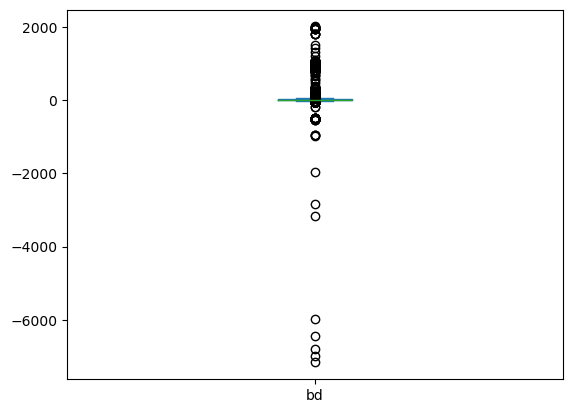

In [26]:
df_members.bd.plot(kind="box")

In [29]:
sum(df_members['bd'] < 0) / df_members.shape[0] # tiny percentage

4.047582433669504e-05

In [31]:
sum(df_members['bd'] > 110) / df_members.shape[0] # another small percentage

0.00036383925307036455

In [36]:
df['bd'] = np.where((df['bd'] > 110) | (df['bd'] < 0), np.nan, df['bd'])

In [38]:
sum(df['bd'].isna()) / df.shape[0]

0.0004043150774070596

## Logs

daily user logs describing listening behaviors of a user. Data collected until 2/28/2017.

    msno: user id
    date: format %Y%m%d
    num_25: # of songs played less than 25% of the song length
    num_50: # of songs played between 25% to 50% of the song length
    num_75: # of songs played between 50% to 75% of of the song length
    num_985: # of songs played between 75% to 98.5% of the song length
    num_100: # of songs played over 98.5% of the song length
    num_unq: # of unique songs played
    total_secs: total seconds played

The v2 file is only march of 2017, and the v1 file is MASSIVE so we are limited to aggregated features on a user level. We'll do EDA on the smaller dataset, and use that to develop our featureset.

In [2]:
df_logs = pd.read_csv('../data/raw/user_logs_v2.csv')

In [3]:
df_logs.head()

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,7100.454
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,28401.558


In [4]:
df_logs.shape

(18396362, 9)

In [5]:
df_logs['msno'].value_counts()

u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=    31
0qLiw20oFg1MBocPTyj3qu37+yWf7UGNz0zekeSpcaM=    31
YWa5GpzNoF6u0117DB+4HgEuBp3IuBxvN+6I/62qoVM=    31
m16fMSTcxvSmxE6dF6XW1n0a9EtWsSz2mz9bfRsZ58w=    31
OI0Vbi3v3D1GOPP/7NTaJrK8vOxSikGirFE+qE2LMYY=    31
                                                ..
U/A6equ77WxREwyiLAUcX6ZCmotzeE02NSsEsXtC3rw=     1
87rzAfuRBvhMWKnO3db3Y0N7gAJh3UW+XtMjQWMhPd0=     1
A1v6d1GV5FaesozhjKKDUF5EDY4NXQD5q0rV2gw5ZvM=     1
jnD1ztRJZku8+nZnM1lvinSVWyzDPgygKEV7lLUIEsk=     1
uLsXcs3ztNgyl5ipvAWS3hcSlQ5bI7OIZBCJkStHSTw=     1
Name: msno, Length: 1103894, dtype: int64

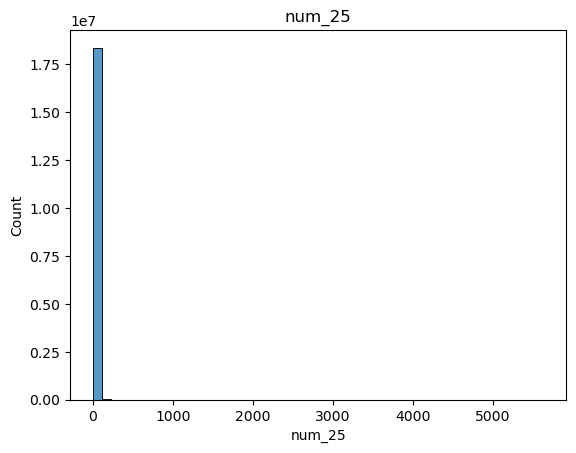

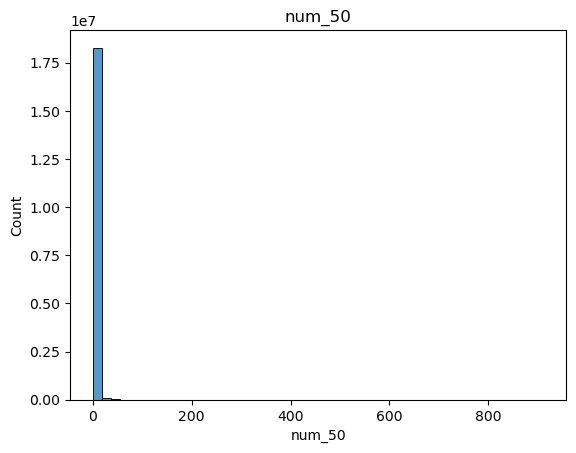

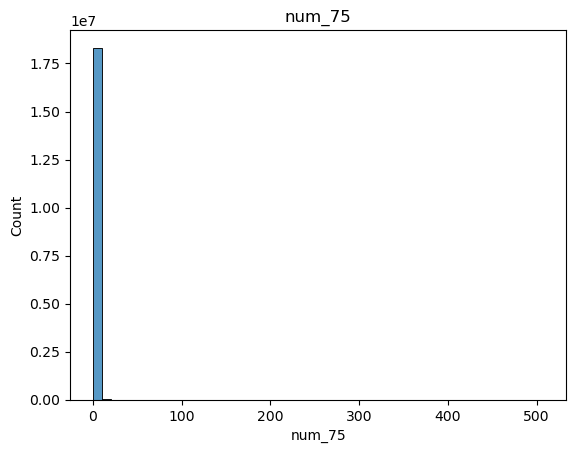

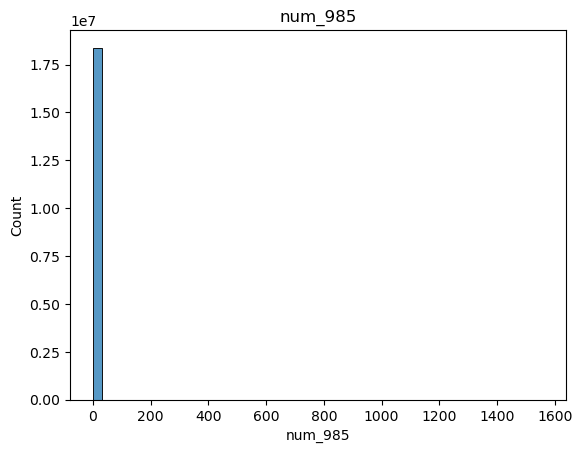

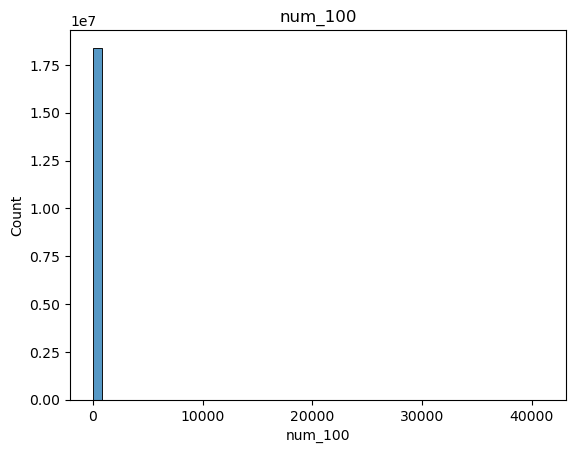

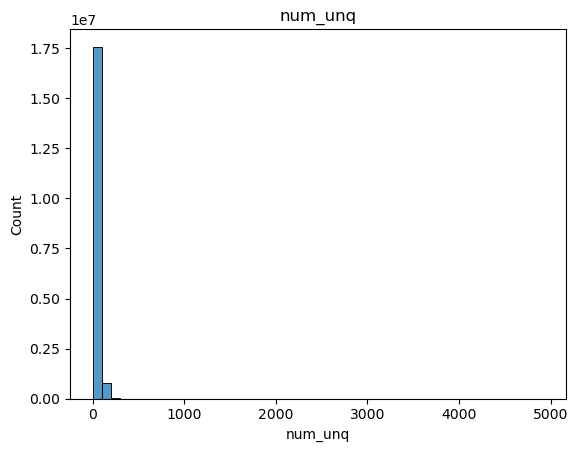

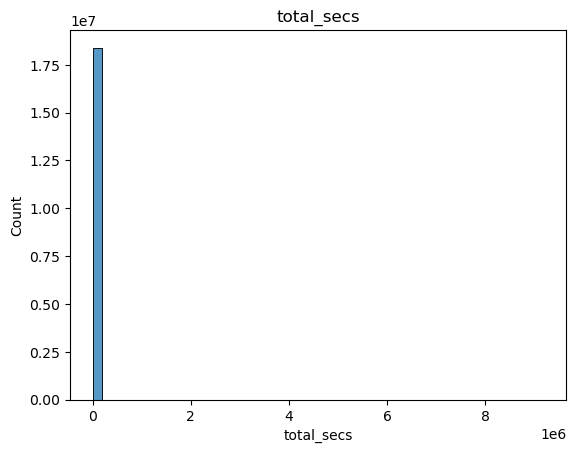

In [7]:
cols = ["num_25","num_50","num_75","num_985","num_100","num_unq","total_secs"]

for col in cols:
    sns.histplot(df_logs[col], bins=50)
    plt.title(col)
    plt.show()

In [9]:
df_logs[cols].describe(percentiles=[.5,.75,.9,.95,.99])

,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
count,1.839636e+07,1.839636e+07,1.839636e+07,1.839636e+07,1.839636e+07,1.839636e+07,1.839636e+07
mean,6.191401e+00,1.508789e+00,9.413759e-01,1.079905e+00,3.028246e+01,2.903615e+01,7.904814e+03
std,1.342827e+01,3.908539e+00,1.924840e+00,3.518409e+00,4.203641e+01,3.219866e+01,1.013632e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e-03
50%,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.700000e+01,1.800000e+01,4.582990e+03
75%,7.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,3.700000e+01,3.800000e+01,9.848441e+03
90%,1.600000e+01,4.000000e+00,3.000000e+00,3.000000e+00,7.500000e+01,6.900000e+01,1.947659e+04
95%,2.500000e+01,6.000000e+00,4.000000e+00,4.000000e+00,1.110000e+02,9.500000e+01,2.818853e+04
99%,5.600000e+01,1.500000e+01,8.000000e+00,9.000000e+00,1.800000e+02,1.490000e+02,4.380552e+04
max,5.639000e+03,9.120000e+02,5.080000e+02,1.561000e+03,4.110700e+04,4.925000e+03,9.194059e+06


In [8]:
df_logs["completion_ratio"] = df_logs["num_100"] / (
    df_logs["num_25"] + df_logs["num_50"] + df_logs["num_75"] + df_logs["num_985"] + df_logs["num_100"]
)

In [11]:
df_logs["skip_ratio"] = df_logs["num_25"] / (
    df_logs["num_25"] + df_logs["num_50"] + df_logs["num_75"] + df_logs["num_985"] + df_logs["num_100"]
)

In [12]:
df_logs["songs_played"] = (
    df_logs["num_25"] + df_logs["num_50"] + df_logs["num_75"] + df_logs["num_985"] + df_logs["num_100"]
)

<Axes: xlabel='songs_played', ylabel='total_secs'>

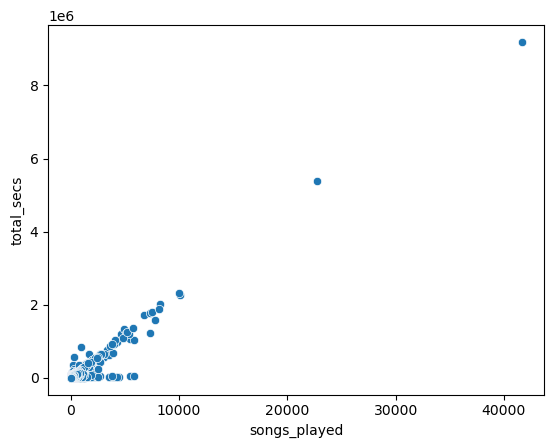

In [14]:
sns.scatterplot(x="songs_played", y="total_secs", data=df_logs)

In [16]:
df_logs["avg_song_secs"] = df_logs["total_secs"] / df_logs["songs_played"]

<Axes: xlabel='repeat_ratio', ylabel='Count'>

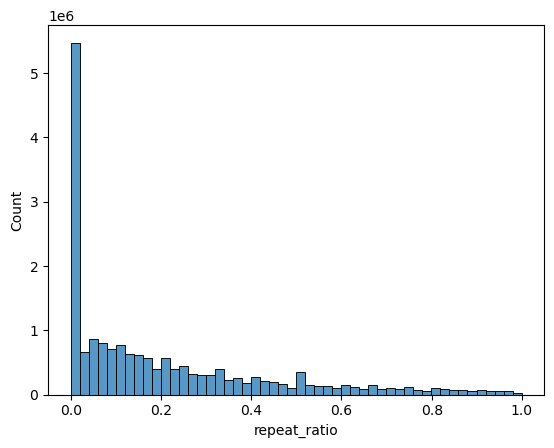

In [17]:
df_logs["repeat_ratio"] = 1 - (df_logs["num_unq"] / df_logs["songs_played"])
sns.histplot(df_logs["repeat_ratio"], bins=50)

In [18]:
df_logs["date"] = pd.to_datetime(df_logs["date"], format="%Y%m%d")

In [25]:
df_logs.date.min()

Timestamp('2017-03-01 00:00:00')

In [26]:
df_logs.date.max()

Timestamp('2017-03-31 00:00:00')

Looks like date is only March of 2017.

<Axes: xlabel='date'>

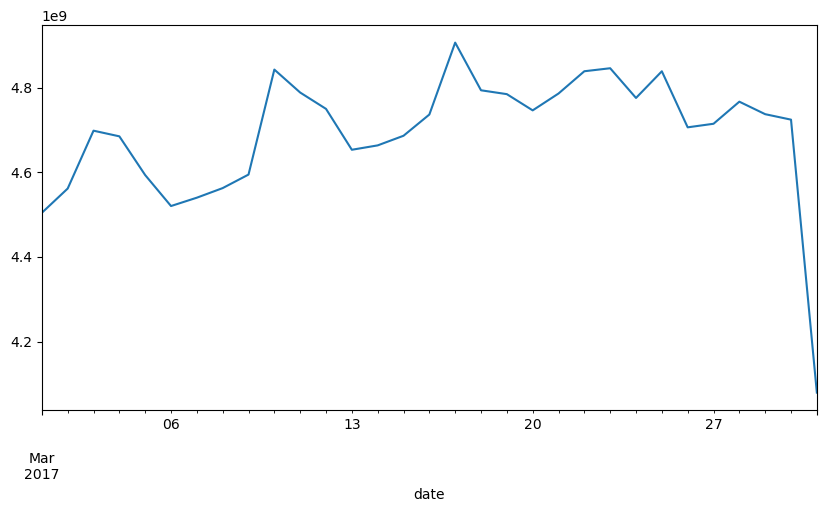

In [19]:
daily = df_logs.groupby("date")["total_secs"].sum()

daily.plot(figsize=(10,5))

In [20]:
user_df = df_logs.groupby("msno").agg({
    "songs_played":"mean",
    "total_secs":"mean",
    "completion_ratio":"mean",
    "skip_ratio":"mean",
    "repeat_ratio":"mean"
}).reset_index()

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = user_df[[
    "completion_ratio",
    "skip_ratio",
    "songs_played",
    "repeat_ratio",
    "total_secs"
]]

X = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=5)
user_df["cluster"] = kmeans.fit_predict(X)

/Users/liamgeron/anaconda3/envs/mlenv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: >

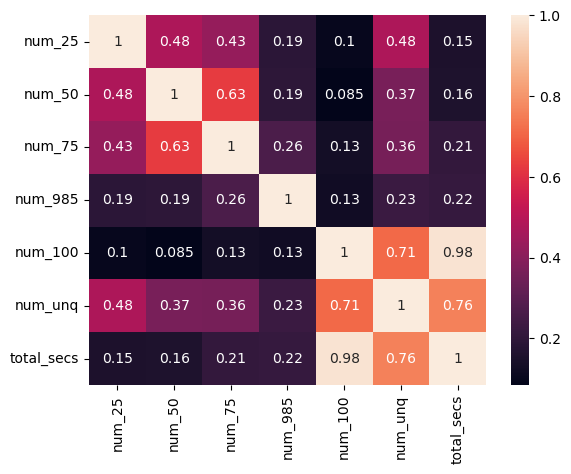

In [22]:
sns.heatmap(df_logs[cols].corr(), annot=True)

<Axes: xlabel='date'>

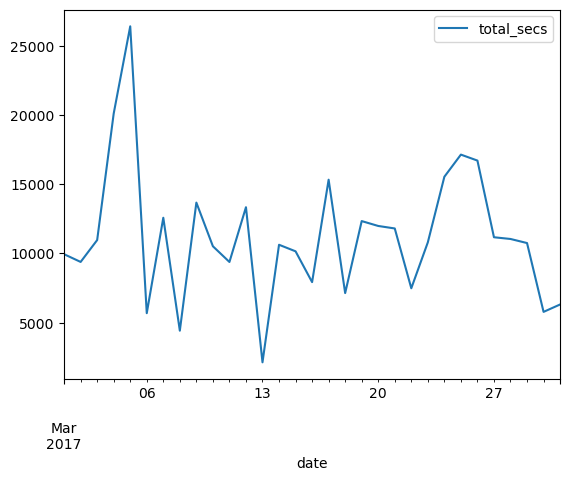

In [23]:
user = df_logs[df_logs["msno"] == df_logs["msno"].iloc[0]]
user.sort_values("date").plot(x="date", y="total_secs")

<Axes: xlabel='total_secs'>

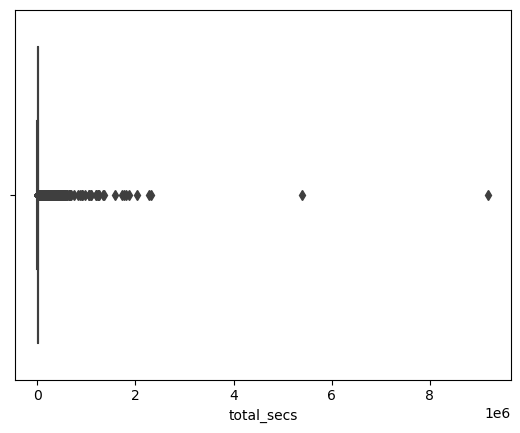

In [24]:
sns.boxplot(x=df_logs["total_secs"]) # HUGE Outliers

## Transactions

transactions of users up until 2/28/2017.

    msno: user id
    payment_method_id: payment method
    payment_plan_days: length of membership plan in days
    plan_list_price: in New Taiwan Dollar (NTD)
    actual_amount_paid: in New Taiwan Dollar (NTD)
    is_auto_renew
    transaction_date: format %Y%m%d
    membership_expire_date: format %Y%m%d
    is_cancel: whether or not the user canceled the membership in this transaction.


In [14]:
df_transactions = pd.read_csv("../data/raw/transactions_v2.csv")

## Train set

the train set, containing the user ids and whether they have churned.

    msno: user id
    is_churn: This is the target variable. Churn is defined as whether the user did not continue the subscription within 30 days of expiration. is_churn = 1 means churn,is_churn = 0 means renewal.


In [15]:
df_train = pd.read_csv("../data/raw/train_v2.csv")